In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data_preprocessed.csv", header=None)
x = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values   


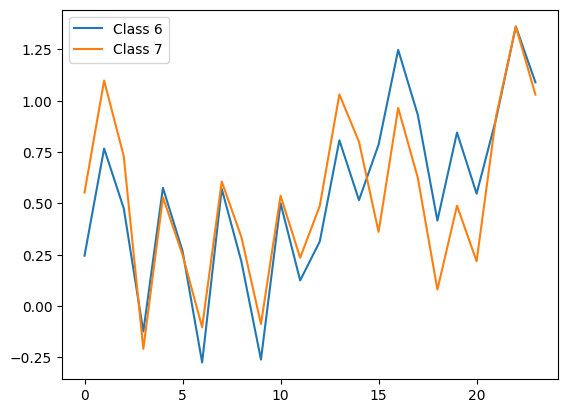

In [3]:
mean6 = x[y == 6].mean(axis=0)
mean7 = x[y == 7].mean(axis=0)

plt.plot(mean6[:200], label="Class 6")
plt.plot(mean7[:200], label="Class 7")
plt.legend()
plt.show()


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

Accuracy: 0.8660773849232822
F1 Score: 0.850432976073387
Classification Report:
              precision    recall  f1-score   support

           0     0.8261    0.3298    0.4714       749
           1     0.8096    0.9653    0.8806       749
           2     0.8850    0.9440    0.9135       750
           3     0.8319    0.9240    0.8756       750
           4     0.8626    0.9373    0.8984       750
           5     0.8482    0.9252    0.8851       749
           6     0.8635    0.9027    0.8827       750
           7     0.9921    1.0000    0.9960       749

    accuracy                         0.8661      5996
   macro avg     0.8649    0.8660    0.8504      5996
weighted avg     0.8649    0.8661    0.8504      5996



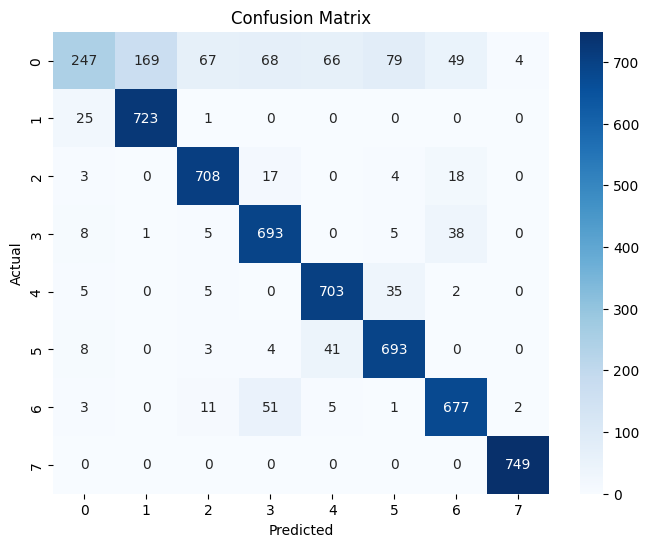

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred, average='weighted'))
print("Classification Report:")
print(classification_report(y_test, pred, digits=4))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

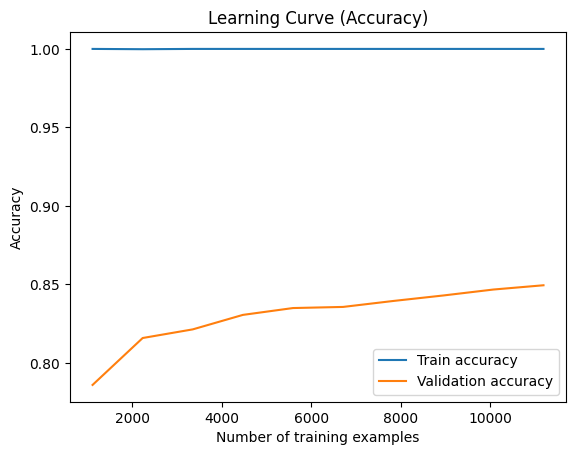

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Produce learning‐curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf,
    X=X_train, y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_means = np.mean(train_scores, axis=1)
test_means  = np.mean(test_scores,  axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_means, label='Train accuracy')
plt.plot(train_sizes, test_means,  label='Validation accuracy')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()


SVM Accuracy: 0.8182121414276184
SVM F1 Score: 0.784844053286276
SVM Classification Report:
              precision    recall  f1-score   support

           0     0.5563    0.1055    0.1773       749
           1     0.6778    0.9773    0.8004       749
           2     0.8890    0.9187    0.9036       750
           3     0.8002    0.9133    0.8531       750
           4     0.8405    0.9067    0.8724       750
           5     0.8258    0.8985    0.8606       749
           6     0.8513    0.8320    0.8415       750
           7     0.9466    0.9933    0.9694       749

    accuracy                         0.8182      5996
   macro avg     0.7984    0.8182    0.7848      5996
weighted avg     0.7985    0.8182    0.7848      5996



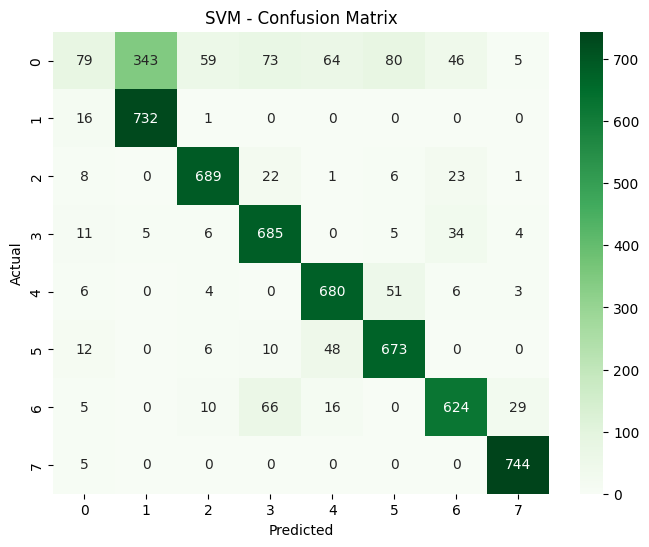

In [6]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("SVM F1 Score:", f1_score(y_test, pred_svm, average='weighted'))
print("SVM Classification Report:")
print(classification_report(y_test, pred_svm, digits=4))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

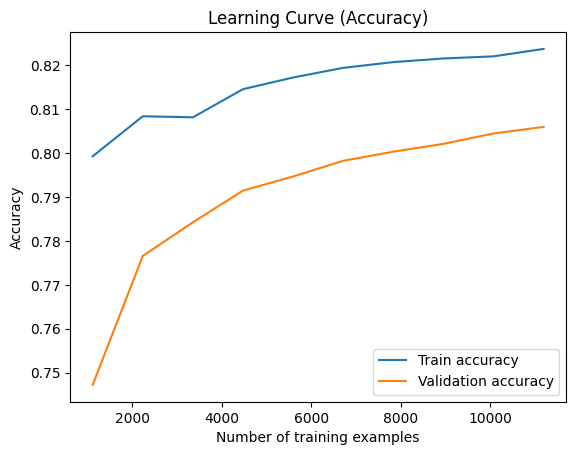

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Produce learning‐curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svm,
    X=X_train, y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_means = np.mean(train_scores, axis=1)
test_means  = np.mean(test_scores,  axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_means, label='Train accuracy')
plt.plot(train_sizes, test_means,  label='Validation accuracy')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()


Decision Tree Accuracy: 0.778685790527018
Decision Tree F1 Score: 0.7761392235848544
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0     0.4055    0.3752    0.3897       749
           1     0.7867    0.8865    0.8336       749
           2     0.8421    0.8320    0.8370       750
           3     0.7907    0.7907    0.7907       750
           4     0.8089    0.7960    0.8024       750
           5     0.7919    0.7824    0.7871       749
           6     0.7997    0.7667    0.7828       750
           7     0.9715    1.0000    0.9855       749

    accuracy                         0.7787      5996
   macro avg     0.7746    0.7787    0.7761      5996
weighted avg     0.7746    0.7787    0.7761      5996



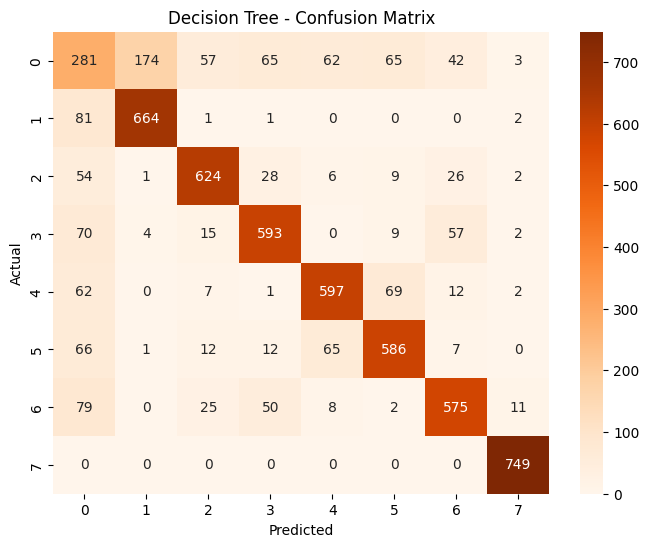

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, pred_dt, average='weighted'))
print("Decision Tree Classification Report:")
print(classification_report(y_test, pred_dt, digits=4))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_dt), annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [8]:
import numpy as np
import math
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
P = len(y)
k = int(math.floor(math.log2(P)))
if k % 2 == 0:
    k += 1
pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=k)
)
pipeline.fit(x, y)
train_acc = pipeline.score(x, y)
print(f"Training accuracy: {train_acc:.4f} using k={k}")


Training accuracy: 0.8301 using k=15


In [9]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, x, y, cv=5, scoring='f1_weighted')
print("Cross-validated F1-score:", scores.mean())
from sklearn.model_selection import cross_val_score
scores = cross_val_score(svm, x, y, cv=5, scoring='f1_weighted')
print("Cross-validated F1-score:", scores.mean())
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f"Cross-validated F1-weighted (5 folds): {np.mean(scores):.4f} (std: {np.std(scores):.4f}), k={k}")


Cross-validated F1-score: 0.8167556642249018
Cross-validated F1-score: 0.763392661175334
Cross-validated F1-weighted (5 folds): 0.7809 (std: 0.0044), k=15
